In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('../data/bitcoin_historical_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.sort_values('Timestamp').reset_index(drop=True)

In [3]:
df['MA_20'] = df['Close'].rolling(window=20).mean()  # 20-day average
df['MA_50'] = df['Close'].rolling(window=50).mean()  # 50-day average
df['MA_200'] = df['Close'].rolling(window=200).mean()  # 200-day average

In [4]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Volatility'] = df['Daily_Return'].rolling(window=20).std()

In [5]:
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'])

In [7]:
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
print("✅ Technical indicators calculated!")
print(f"\nDataset now has {len(df.columns)} columns")
print(df.head())

✅ Technical indicators calculated!

Dataset now has 16 columns
            Timestamp  Open  High   Low  Close  Volume  MA_20  MA_50  MA_200  \
0 2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0    NaN    NaN     NaN   
1 2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0    NaN    NaN     NaN   
2 2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0    NaN    NaN     NaN   
3 2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0    NaN    NaN     NaN   
4 2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0    NaN    NaN     NaN   

   Daily_Return  Volatility  RSI  EMA_12  EMA_26  MACD  Signal  
0           NaN         NaN  NaN    4.58    4.58   0.0     0.0  
1           0.0         NaN  NaN    4.58    4.58   0.0     0.0  
2           0.0         NaN  NaN    4.58    4.58   0.0     0.0  
3           0.0         NaN  NaN    4.58    4.58   0.0     0.0  
4           0.0         NaN  NaN    4.58    4.58   0.0     0.0  


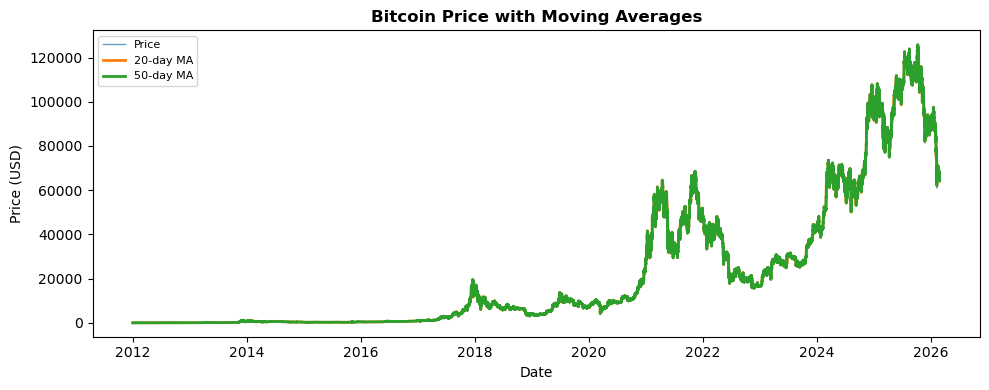

In [9]:
# VISUALIZATION 1: Price with Moving Averages
df_sample = df.iloc[::50, :].reset_index(drop=True)
plt.figure(figsize=(10, 4))
plt.plot(df_sample['Timestamp'], df_sample['Close'], label='Price', linewidth=1, alpha=0.7)
plt.plot(df_sample['Timestamp'], df_sample['MA_20'], label='20-day MA', linewidth=2)
plt.plot(df_sample['Timestamp'], df_sample['MA_50'], label='50-day MA', linewidth=2)
plt.title('Bitcoin Price with Moving Averages', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

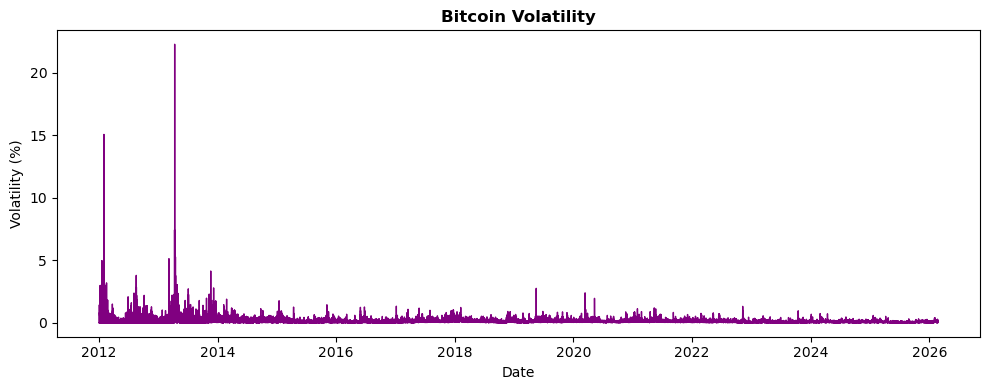

In [10]:
# VISUALIZATION 2: Volatility
plt.figure(figsize=(10, 4))
plt.plot(df_sample['Timestamp'], df_sample['Volatility'], color='purple', linewidth=1)
plt.title('Bitcoin Volatility', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.tight_layout()
plt.show()

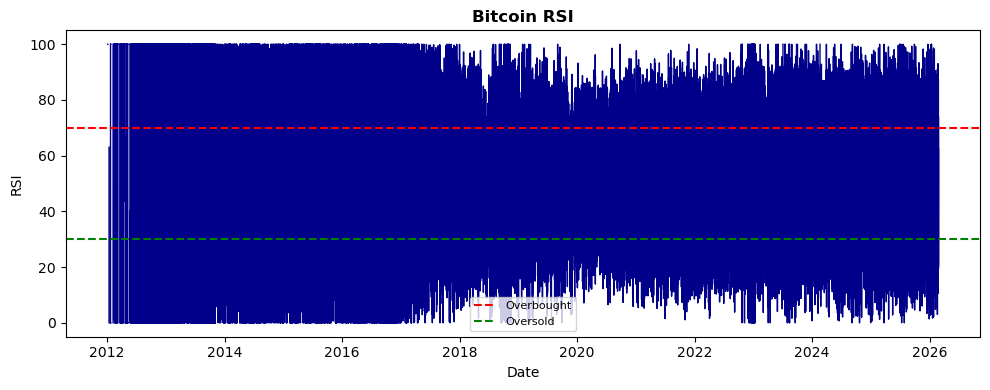

In [11]:
# VISUALIZATION 3: RSI
plt.figure(figsize=(10, 4))
plt.plot(df_sample['Timestamp'], df_sample['RSI'], color='darkblue', linewidth=1)
plt.axhline(y=70, color='r', linestyle='--', label='Overbought')
plt.axhline(y=30, color='g', linestyle='--', label='Oversold')
plt.title('Bitcoin RSI', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

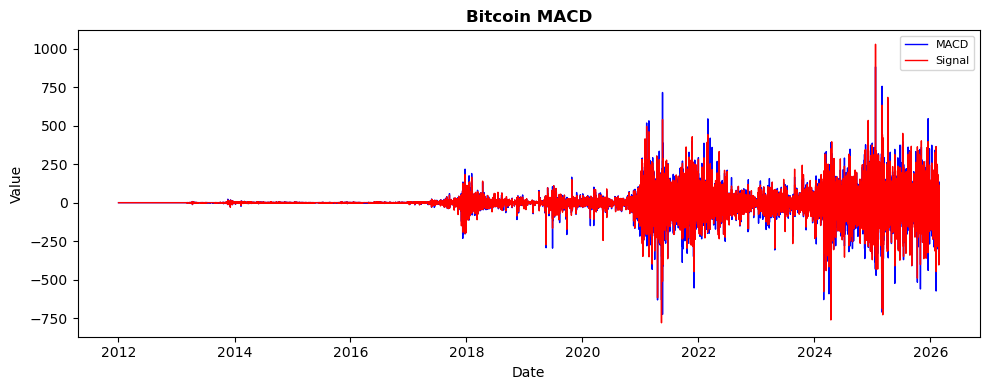

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df_sample['Timestamp'], df_sample['MACD'], label='MACD', color='blue', linewidth=1)
plt.plot(df_sample['Timestamp'], df_sample['Signal'], label='Signal', color='red', linewidth=1)
plt.title('Bitcoin MACD', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()